# 01 — Core Grading Pipeline

Card detection, deskew, sub-score analysis, PSA grade estimate, and batch processing.

> **Run this notebook first.** All other notebooks build on the shared functions in `grading_utils.py`.

## Setup

In [ ]:
# ── Install dependencies (run once, then comment out) ─────────────
import subprocess, sys
packages = ['ultralytics','opencv-python','numpy','Pillow',
            'matplotlib','scipy','scikit-image','ipywidgets']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)

# ── Core functions from grading_utils ────────────────────────────
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('grading_utils.py')))
from grading_utils import *

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.facecolor']  = '#0d1117'
plt.rcParams['figure.facecolor']= '#0d1117'
plt.rcParams['text.color']      = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color']     = 'white'
plt.rcParams['ytick.color']     = 'white'

print('✅ Core pipeline ready')

## 10. Load YOLOv8 (Optional — skip if running on CPU only)

We use `yolov8n-seg` (nano segmentation) — small and fast.
On first run it downloads ~12 MB automatically.

If you have a custom model trained on card images, set `MODEL_PATH` to that checkpoint.

In [11]:
from ultralytics import YOLO

# Options:
#   'yolov8n-seg.pt'  — nano, fastest (~12 MB)
#   'yolov8s-seg.pt'  — small, better accuracy (~22 MB)
#   'path/to/custom.pt' — your own trained model
MODEL_PATH = 'yolov8n-seg.pt'

yolo_model = YOLO(MODEL_PATH)
print(f'✅ YOLOv8 loaded: {MODEL_PATH}')

# NOTE: The pre-trained COCO model won't have a "trading card" class.
# It will try to match the card to the nearest COCO class (often "book" or
# "cell phone"). For best results, train a custom model on card images.
# The contour fallback works well for clean backgrounds.

✅ YOLOv8 loaded: yolov8n-seg.pt


## 11. Analyze a Single Card

Set `IMAGE_PATH` to your card image (JPG, PNG, HEIC all work).

In [12]:
# ── SET YOUR IMAGE PATH HERE ──────────────────────────────────────
IMAGE_PATH = 'sample_card.jpg'   # ← replace with your card image
IMAGE_PATH = 'image0_back.jpeg'
# ─────────────────────────────────────────────────────────────────

# Set yolo_model=None to skip YOLO and use contour detection only
report = grade_card(IMAGE_PATH, yolo_model=yolo_model)

print(f'\n{"-"*50}')
print(f'  {report.psa_label}')
print(f'  Composite score: {report.composite:.1f} / 100')
print(f'  Confidence: {report.confidence}')
print(f'{"-"*50}')
print(f'  Corners:   {report.sub_scores["corners"]:.1f}/100')
print(f'  Centering: {report.sub_scores["centering"]:.1f}/100  ({report.centering.grade})')
print(f'  Edges:     {report.sub_scores["edges"]:.1f}/100')
print(f'  Surface:   {report.sub_scores["surface"]:.1f}/100')
print(f'{"-"*50}\n')


--------------------------------------------------
  PSA 1 (Poor)
  Composite score: 12.0 / 100
  Confidence: High
--------------------------------------------------
  Corners:   8.8/100
  Centering: 20.0/100  (75/25+)
  Edges:     0.6/100
  Surface:   25.5/100
--------------------------------------------------



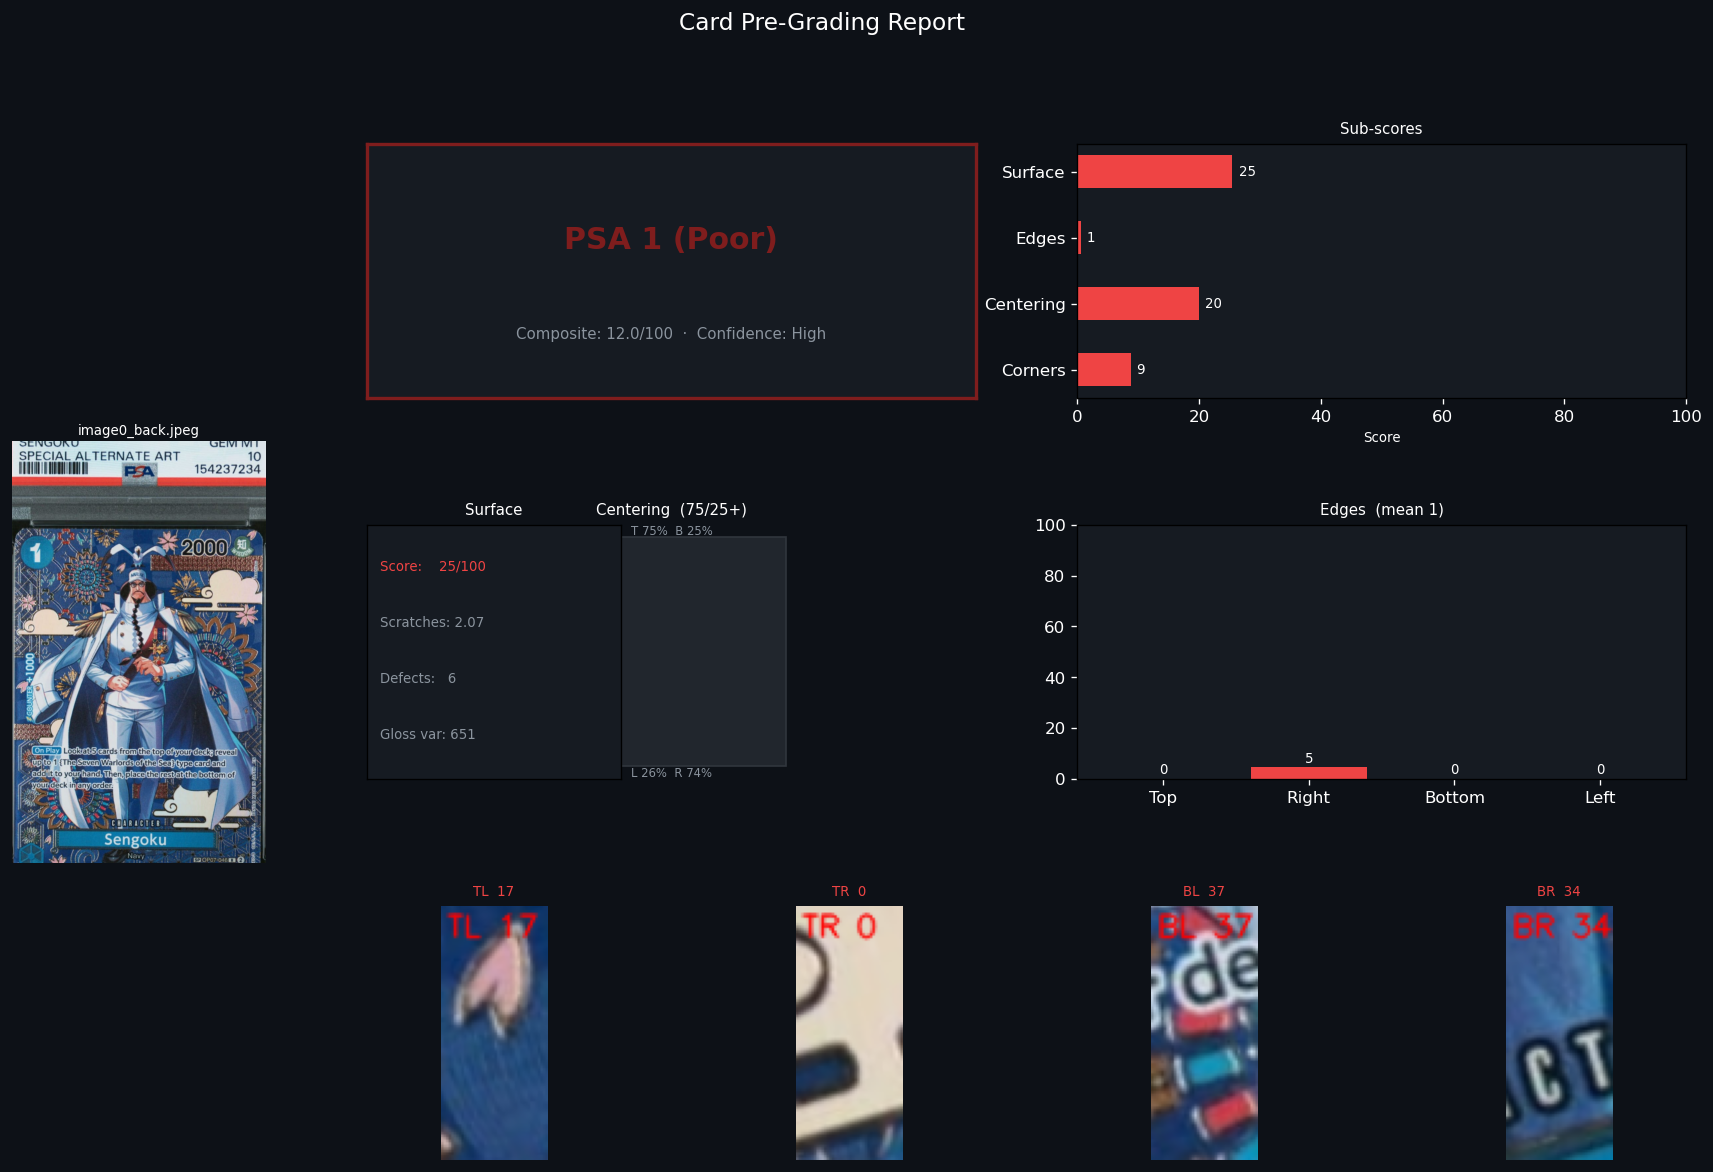

In [13]:
# Full visual dashboard
plot_report(report, IMAGE_PATH)

## 12. Batch Processing

Grade a folder of card images and export results to CSV.

In [14]:
import csv
from tqdm.notebook import tqdm

# ── CONFIG ────────────────────────────────────────────────────────
CARD_FOLDER  = Path('cards/')        # folder of card images
OUTPUT_CSV   = Path('grades.csv')    # output file
# ─────────────────────────────────────────────────────────────────

image_paths = sorted([
    p for p in CARD_FOLDER.iterdir()
    if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.webp')
])

print(f'Found {len(image_paths)} images in {CARD_FOLDER}')

results = []
for path in tqdm(image_paths, desc='Grading'):
    try:
        r = grade_card(str(path), yolo_model=yolo_model)
        results.append({
            'file':          path.name,
            'psa_estimate':  int(r.psa_estimate),
            'psa_label':     r.psa_label,
            'composite':     round(r.composite, 1),
            'corners':       round(r.sub_scores['corners'], 1),
            'centering':     round(r.sub_scores['centering'], 1),
            'centering_ratio': r.centering.grade,
            'edges':         round(r.sub_scores['edges'], 1),
            'surface':       round(r.sub_scores['surface'], 1),
            'confidence':    r.confidence,
        })
    except Exception as e:
        print(f'  ⚠ {path.name}: {e}')
        results.append({'file': path.name, 'psa_estimate': None, 'error': str(e)})

# Write CSV
if results:
    keys = [k for k in results[0] if k != 'error']
    with open(OUTPUT_CSV, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys + ['error'], extrasaction='ignore')
        w.writeheader()
        w.writerows(results)
    print(f'\n✅ Saved {len(results)} results to {OUTPUT_CSV}')

Found 3 images in cards


Grading:   0%|          | 0/3 [00:00<?, ?it/s]


✅ Saved 3 results to grades.csv


## 13. Grade Distribution (Batch Summary)

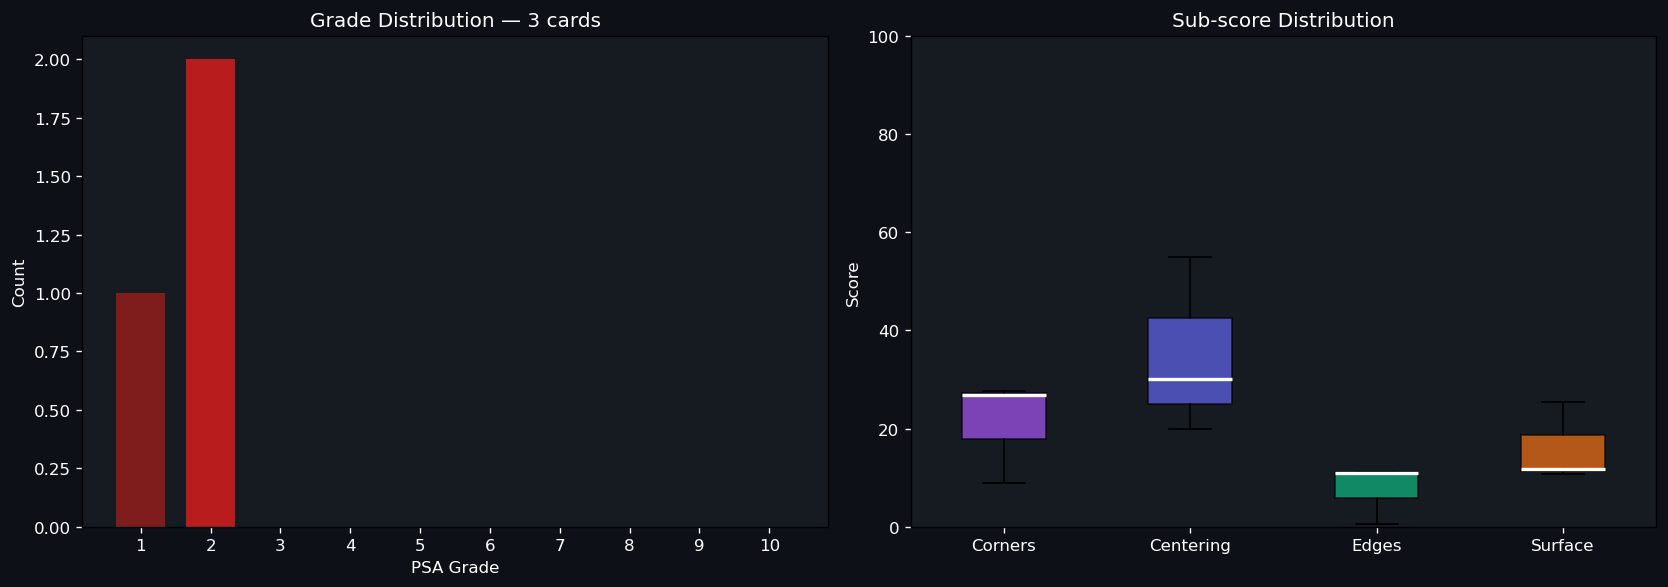


Median grade:   PSA 2
Mean grade:     PSA 1.7
PSA 9+ cards:   0 / 3
PSA 8+ cards:   0 / 3


In [15]:
if results:
    valid = [r for r in results if r.get('psa_estimate')]
    grades = [r['psa_estimate'] for r in valid]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d1117')

    # ── Grade distribution bar chart ──────────────────────────────
    ax1 = axes[0]
    ax1.set_facecolor('#161b22')
    grade_counts = {g: grades.count(g) for g in range(1, 11)}
    ax1.bar(
        grade_counts.keys(),
        grade_counts.values(),
        color=[GRADE_COLORS[g] for g in grade_counts.keys()],
        width=0.7,
    )
    ax1.set_xlabel('PSA Grade', color='white')
    ax1.set_ylabel('Count', color='white')
    ax1.set_title(f'Grade Distribution — {len(valid)} cards', color='white')
    ax1.set_xticks(range(1, 11))
    ax1.tick_params(colors='white')

    # ── Sub-score box plots ───────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#161b22')
    dims = ['corners', 'centering', 'edges', 'surface']
    data = [[r[d] for r in valid if d in r] for d in dims]
    bp   = ax2.boxplot(data, labels=[d.capitalize() for d in dims],
                       patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})
    colors_box = ['#a855f7', '#6366f1', '#10b981', '#f97316']
    for patch, clr in zip(bp['boxes'], colors_box):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax2.set_ylabel('Score', color='white')
    ax2.set_title('Sub-score Distribution', color='white')
    ax2.set_ylim(0, 100)
    ax2.tick_params(colors='white')

    plt.tight_layout()
    plt.show()

    print(f'\nMedian grade:   PSA {int(np.median(grades))}')
    print(f'Mean grade:     PSA {np.mean(grades):.1f}')
    print(f'PSA 9+ cards:   {sum(1 for g in grades if g >= 9)} / {len(grades)}')
    print(f'PSA 8+ cards:   {sum(1 for g in grades if g >= 8)} / {len(grades)}')